# Digits Generation with Auto Encoder
## Import Packages

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import time
import pandas as pd

2021-09-20 15:33:47.847645: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0


## Utilities

In [2]:
def sample_images(images, row_count, column_count):
    fig, axs = plt.subplots(row_count, column_count, figsize=(10,10))
    for i in range(row_count):
        for j in range(column_count):
            axs[i,j].imshow(images[i * column_count + j])
            axs[i,j].axis('off')
    plt.show()

## Import Datasets

In [3]:
batch_size = 100
n_epochs = 10
image_width = 32

In [4]:
def preproces_image(item):
    image = item["image"]
    image = tf.cast(image, "float")  / 255.0
    image =tf.image.resize(image, (image_width, image_width))
    return image, image

In [5]:
train = tfds.load("mnist", split='train', as_supervised=False).map(preproces_image).shuffle(1024).batch(batch_size, drop_remainder=True).prefetch(1)
test = tfds.load("mnist", split='test', as_supervised=False).map(preproces_image).shuffle(1024).batch(batch_size, drop_remainder=True).prefetch(1)

Dl Completed...:   0%|          | 0/4 [00:00<?, ? file/s]


Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


2021-09-20 15:33:53.519577: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-09-20 15:33:53.522582: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2021-09-20 15:33:53.571818: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-09-20 15:33:53.572452: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:00:04.0 name: Tesla P100-PCIE-16GB computeCapability: 6.0
coreClock: 1.3285GHz coreCount: 56 deviceMemorySize: 15.90GiB deviceMemoryBandwidth: 681.88GiB/s
2021-09-20 15:33:53.572503: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2021-09-20 15:33:53.598150: I tensorflow/stream_executor/platform/def

2021-09-20 15:33:55.427278: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2021-09-20 15:33:55.430791: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2000175000 Hz


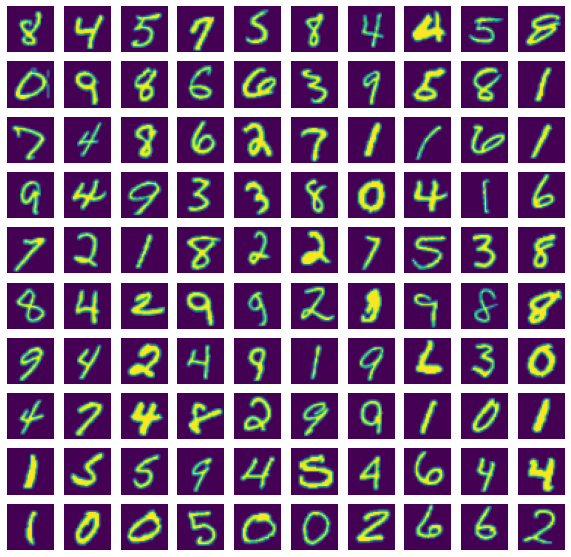

2021-09-20 15:33:59.788331: W tensorflow/core/kernels/data/cache_dataset_ops.cc:757] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [6]:
for images, _ in train.take(1):
    sample_images(images, 10, 10)

## Build the Auto Encoder

In [7]:
tf.keras.backend.clear_session()

In [8]:
AE = keras.models.Sequential([
    keras.layers.Conv2D(32, 3, strides=2, padding="same", activation="relu", input_shape=(image_width, image_width, 1)),
    keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu"),
    keras.layers.UpSampling2D(2),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.UpSampling2D(2),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.UpSampling2D(2),
    keras.layers.Conv2D(1, 3, padding="same", activation="relu")
])
AE.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 16, 16, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 8, 8, 64)          18496     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 4, 4, 128)         73856     
_________________________________________________________________
up_sampling2d (UpSampling2D) (None, 8, 8, 128)         0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 8, 8, 64)          73792     
_________________________________________________________________
up_sampling2d_1 (UpSampling2 (None, 16, 16, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 16, 16, 32)        1

In [9]:
AE.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])

## Train the Model

In [10]:
history = AE.fit(train, epochs=20)

Epoch 1/20


2021-09-20 15:34:00.877247: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.8
2021-09-20 15:34:06.071958: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11


  1/600 [..............................] - ETA: 1:07:01 - loss: 0.0974 - mae: 0.1364

2021-09-20 15:34:06.810116: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.11


600/600 [==============================] - 18s 19ms/step - loss: 0.0137 - mae: 0.0471
Epoch 2/20
600/600 [==============================] - 5s 8ms/step - loss: 0.0019 - mae: 0.0163
Epoch 3/20
600/600 [==============================] - 5s 8ms/step - loss: 0.0013 - mae: 0.0138
Epoch 4/20
600/600 [==============================] - 5s 9ms/step - loss: 0.0011 - mae: 0.0125
Epoch 5/20
600/600 [==============================] - 5s 8ms/step - loss: 9.2806e-04 - mae: 0.0116
Epoch 6/20
600/600 [==============================] - 5s 8ms/step - loss: 8.0546e-04 - mae: 0.0109
Epoch 7/20
600/600 [==============================] - 5s 9ms/step - loss: 7.1395e-04 - mae: 0.0102
Epoch 8/20
600/600 [==============================] - 5s 8ms/step - loss: 6.5652e-04 - mae: 0.0098
Epoch 9/20
600/600 [==============================] - 5s 9ms/step - loss: 5.9966e-04 - mae: 0.0094
Epoch 10/20
600/600 [==============================] - 6s 9ms/step - loss: 5.7300e-04 - mae: 0.0092
Epoch 11/20
600/600 [=============

## Model Evaluation

<AxesSubplot:>

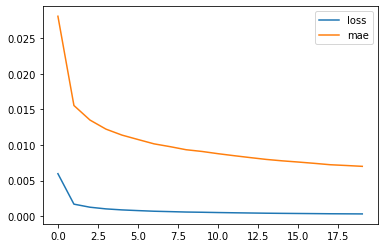

In [11]:
pd.DataFrame(history.history).plot()

## 

In [12]:
mse, mae = AE.evaluate(test)
print("MSE:", mse)
print("MAE:", mae)

100/100 [==============================] - 2s 17ms/step - loss: 3.1638e-04 - mae: 0.0069
MSE: 0.00031637598294764757
MAE: 0.006919546518474817


## Encode the test images

In [13]:
result = AE.predict(test)
result.shape

(10000, 32, 32, 1)

## 

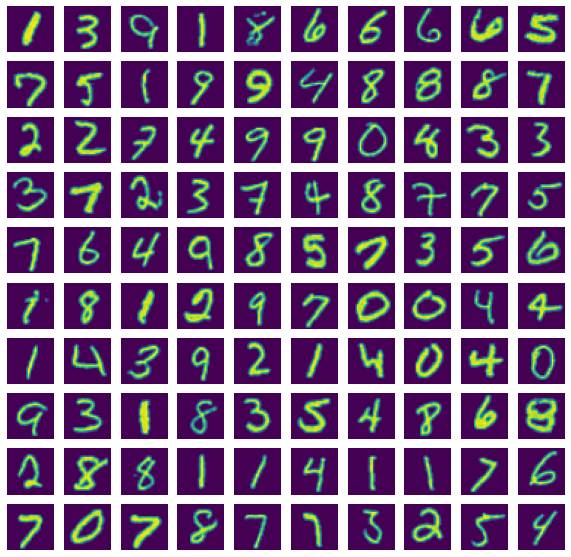

In [14]:
indices = np.random.choice(result.shape[0], 100)
sample_images(result[indices], 10, 10)

## Save the Model

In [15]:
AE.save("AE.h5")